# Accelerated Stability Analysis — Lot A014 vs Lot B025

Pre-interview data exercise. Two formulations exposed to elevated temperature
and humidity for varying durations; three responses measured in duplicate:
assay (potency), Imp RRT 0.92, and Imp RRT 1.23.

> Place `KTP_task_datasets.xls` in `./data/` before running.

## 0. Load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

COLS = ["start","pull","setdown","exposure","oven","T","RH","analyst",
        "assay_1","assay_2","imp092_1","imp092_2","imp123_1","imp123_2"]

def load(sheet):
    raw = pd.read_excel("data/KTP_task_datasets.xls", engine="xlrd",
                        sheet_name=sheet, header=None)
    df = raw.iloc[2:].copy()
    df.columns = COLS
    df = df.reset_index(drop=True)
    num = ["exposure","assay_1","assay_2","imp092_1","imp092_2","imp123_1","imp123_2"]
    for c in num:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["oven"] = df["oven"].astype(str).str.strip()
    df["T"]  = pd.to_numeric(df["T"],  errors="coerce")
    df["RH"] = pd.to_numeric(df["RH"], errors="coerce")
    df["lot"] = sheet
    df["assay"]  = df[["assay_1",  "assay_2" ]].mean(axis=1)
    df["imp092"] = df[["imp092_1", "imp092_2"]].mean(axis=1)
    df["imp123"] = df[["imp123_1", "imp123_2"]].mean(axis=1)
    df["is_control"] = df["oven"].str.startswith("n/a")
    return df

df = pd.concat([load(s) for s in ["Lot A014","Lot B025"]], ignore_index=True)
stressed = df[~df.is_control].copy()
control  = df[df.is_control].copy()
print(f"Stressed: {len(stressed)} rows | Controls: {len(control)} rows")
df[["lot","T","RH","exposure","assay","imp092","imp123"]].head(6)

Stressed: 38 rows | Controls: 2 rows


,lot,T,RH,exposure,assay,imp092,imp123
0,Lot A014,70.0,11.0,21,8.1520,0.2850,0.0740
1,Lot A014,65.0,25.0,21,10.9430,0.2305,0.1350
2,Lot A014,50.0,64.0,21,12.1690,0.2220,0.1900
3,Lot A014,60.0,80.0,21,11.3065,0.6620,0.1690
4,Lot A014,60.0,42.0,21,11.5535,0.5340,0.1760
5,Lot A014,60.0,21.0,21,11.7035,0.3015,0.1645


## Q1. Key features of the dataset

In [2]:
# Conditions and structure
print("Temperatures (°C):", sorted(stressed["T"].dropna().unique()))
print("Relative humidities (%):", sorted(stressed["RH"].dropna().unique()))
print("Exposure times (days):", sorted(stressed.exposure.unique()))

# Paired design check — same conditions on both lots?
keyA = set(stressed[stressed.lot=="Lot A014"][["T","RH","exposure"]].apply(tuple,axis=1))
keyB = set(stressed[stressed.lot=="Lot B025"][["T","RH","exposure"]].apply(tuple,axis=1))
print(f"\nConditions in A: {len(keyA)}, in B: {len(keyB)}, shared: {len(keyA & keyB)}")
print("=> Fully paired design")

Temperatures (°C): [np.float64(50.0), np.float64(60.0), np.float64(65.0), np.float64(70.0)]
Relative humidities (%): [np.float64(11.0), np.float64(21.0), np.float64(25.0), np.float64(41.0), np.float64(42.0), np.float64(63.0), np.float64(64.0), np.float64(79.0), np.float64(80.0)]
Exposure times (days): [np.int64(1), np.int64(2), np.int64(5), np.int64(6), np.int64(7), np.int64(14), np.int64(17), np.int64(19), np.int64(20), np.int64(21)]

Conditions in A: 19, in B: 19, shared: 19
=> Fully paired design


In [3]:
# Duplicate measurement precision
for name, c1, c2 in [("Assay","assay_1","assay_2"),
                      ("Imp 0.92","imp092_1","imp092_2"),
                      ("Imp 1.23","imp123_1","imp123_2")]:
    diff = (df[c1] - df[c2]).abs()
    print(f"{name:10s} — mean duplicate diff: {diff.mean():.4f}, max: {diff.max():.4f}")

Assay      — mean duplicate diff: 0.2137, max: 0.5190
Imp 0.92   — mean duplicate diff: 0.0191, max: 0.1220
Imp 1.23   — mean duplicate diff: 0.0035, max: 0.0140


**Observations:**
- Two lots, 19 stressed conditions each (identical), 1 unstressed control each — a **paired design**.
- All samples pulled on the same date; exposure = pull date minus set-down date (staggered start).
- Duplicate analytical precision is tight across all three responses
- **Important:** temperature, humidity and time are not fully independent in this design
  (e.g. 50 °C only appears at long exposures).

## Q2. Trends and patterns

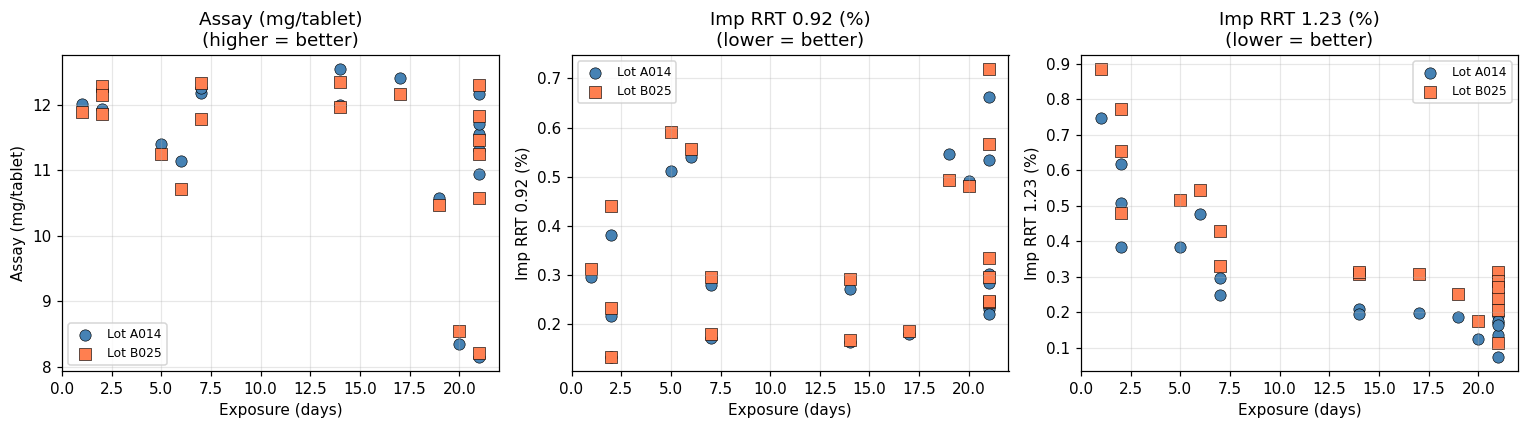

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, resp, ylabel, note in zip(
        axes,
        ["assay","imp092","imp123"],
        ["Assay (mg/tablet)","Imp RRT 0.92 (%)","Imp RRT 1.23 (%)"],
        ["higher = better","lower = better","lower = better"]):
    for lot, marker, color in zip(["Lot A014","Lot B025"],["o","s"],["steelblue","coral"]):
        s = stressed[stressed.lot == lot]
        ax.scatter(s.exposure, s[resp], label=lot, marker=marker,
                   color=color, s=55, edgecolor="k", linewidth=0.4)
    ax.set_xlabel("Exposure (days)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel}\n({note})")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [5]:
# Fixed-exposure slice: only the 6 conditions set down on Day 0 (full 21 days)
# This isolates the temperature/humidity effect cleanly
e21 = stressed[stressed.exposure == 21].sort_values(["lot","T"])
print("21-day conditions — assay by temperature:")
print(e21[["lot","T","RH","assay","imp092","imp123"]].to_string(index=False))

21-day conditions — assay by temperature:
     lot    T   RH   assay  imp092  imp123
Lot A014 50.0 64.0 12.1690  0.2220  0.1900
Lot A014 60.0 80.0 11.3065  0.6620  0.1690
Lot A014 60.0 42.0 11.5535  0.5340  0.1760
Lot A014 60.0 21.0 11.7035  0.3015  0.1645
Lot A014 65.0 25.0 10.9430  0.2305  0.1350
Lot A014 70.0 11.0  8.1520  0.2850  0.0740
Lot B025 50.0 64.0 12.2995  0.2470  0.3140
Lot B025 60.0 80.0 11.2465  0.7185  0.2400
Lot B025 60.0 42.0 11.4585  0.5665  0.2890
Lot B025 60.0 21.0 11.8255  0.3355  0.2700
Lot B025 65.0 25.0 10.5695  0.2460  0.2060
Lot B025 70.0 11.0  8.2160  0.2955  0.1130


**Observations:**
- **Assay falls with temperature**. At 21 days (all set down together), potency drops
  steadily from ~12.2 mg at 50 °C to ~8.2 mg at 70 °C — a clean temperature signal.
- **Imp 1.23 rises over the study period**, but its apparent relationship with time is
  confounded by the staggered design (see Q3).
- **Imp 0.92 peaks at mid-high temperature + high humidity** (~60 °C / 80% RH),
  hinting at a moisture-sensitive degradation route.
- Both lots track each other closely across all conditions.

## Q3. Factors influencing degradation

In [6]:
# Simple correlation table — read alongside the confound caveat
corr = stressed[["T","RH","exposure","assay","imp092","imp123"]].corr().round(2)
print("Correlation matrix (Pearson):")
print(corr[["assay","imp092","imp123"]])

Correlation matrix (Pearson):
          assay  imp092  imp123
T         -0.55    0.41    0.35
RH         0.33    0.05    0.36
exposure  -0.44    0.20   -0.84
assay      1.00   -0.37    0.41
imp092    -0.37    1.00   -0.01
imp123     0.41   -0.01    1.00


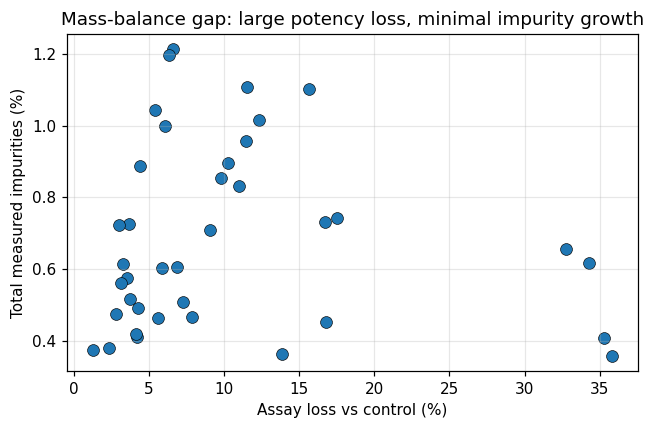

     lot    T   RH  exposure  assay_loss_pct  total_imp
Lot A014 70.0 11.0        21           35.82       0.36
Lot B025 70.0 11.0        21           35.32       0.41
Lot A014 70.0 41.0        20           34.29       0.62
Lot B025 70.0 41.0        20           32.76       0.66


In [7]:
# Mass-balance check — where does the active go at high temperature?
ctrl_assay = control.groupby("lot")["assay"].mean().mean()
mb = stressed.assign(
    assay_loss_pct = (ctrl_assay - stressed.assay) / ctrl_assay * 100,
    total_imp      = stressed.imp092 + stressed.imp123)

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(mb.assay_loss_pct, mb.total_imp, s=60, edgecolor="k", linewidth=0.4)
ax.set_xlabel("Assay loss vs control (%)")
ax.set_ylabel("Total measured impurities (%)")
ax.set_title("Mass-balance gap: large potency loss, minimal impurity growth")
plt.tight_layout()
plt.show()

worst = mb.sort_values("assay_loss_pct", ascending=False).head(4)
print(worst[["lot","T","RH","exposure","assay_loss_pct","total_imp"]].round(2).to_string(index=False))

**Findings:**

- **Temperature** is the strongest driver of potency loss (r ≈ −0.55) and impurity
  formation (r ≈ +0.41 for imp092).
- **Exposure time** correlates with Imp 1.23 (r ≈ −0.84 — *negative*, which is
  implausible). This is a **design artefact**: the longest exposures happen to be at
  lower humidity, and imp123 is humidity-sensitive. Do not read this as a protective
  effect of time.

- **Critical limitation — mass-balance gap.** At the worst conditions, ~35% of
  potency is lost while total measured impurities stay at ~0.4%. The "missing" active
  is unaccounted for. This means potency loss here is **not** simply explained by the
  measured degradants — the mechanism is unknown from this data (could be
  volatilisation, an unmeasured degradant, or a sampling artefact). Any shelf-life
  prediction based on assay alone would be unreliable.

## Q4. Comparing the two formulations

In [8]:
# Paired comparison — same conditions in both lots
pair = pd.merge(
    stressed[stressed.lot=="Lot A014"][["T","RH","exposure","assay","imp092","imp123"]],
    stressed[stressed.lot=="Lot B025"][["T","RH","exposure","assay","imp092","imp123"]],
    on=["T","RH","exposure"], suffixes=("_A","_B"))

results = []
for r, label in [("assay","Assay"),("imp092","Imp 0.92"),("imp123","Imp 1.23")]:
    diff = pair[f"{r}_B"] - pair[f"{r}_A"]
    results.append({"Response": label,
                    "Mean A": pair[f"{r}_A"].mean(),
                    "Mean B": pair[f"{r}_B"].mean(),
                    "Mean diff (B − A)": diff.mean(),
                    "B worse in N/19": int((diff > 0).sum()) if r != "assay"
                                       else int((diff < 0).sum())})
pd.DataFrame(results).round(4)

,Response,Mean A,Mean B,Mean diff (B − A),B worse in N/19
0,Assay,11.4232,11.3339,-0.0893,13
1,Imp 0.92,0.3379,0.3566,0.0186,17
2,Imp 1.23,0.2886,0.3892,0.1006,19


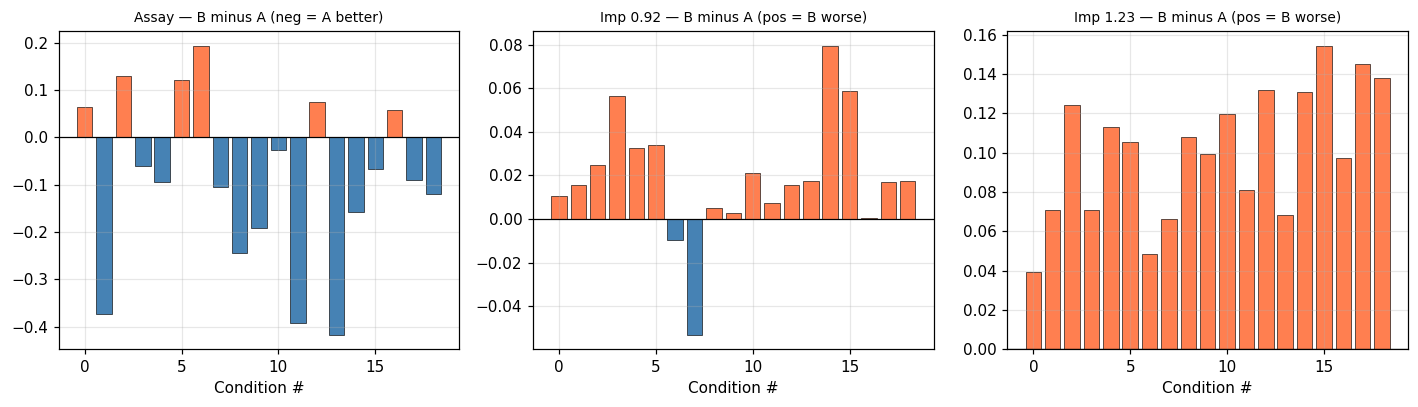

In [9]:
# Visual: B minus A for each response across all 19 paired conditions
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, r, title in zip(axes,
        ["assay","imp092","imp123"],
        ["Assay — B minus A (neg = A better)",
         "Imp 0.92 — B minus A (pos = B worse)",
         "Imp 1.23 — B minus A (pos = B worse)"]):
    diff = pair[f"{r}_B"] - pair[f"{r}_A"]
    ax.bar(range(len(diff)), diff,
           color=["coral" if x > 0 else "steelblue" for x in diff],
           edgecolor="k", linewidth=0.4)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Condition #")
plt.tight_layout()
plt.show()

**Recommendation:**

- **Potency:** the two formulations are **essentially equivalent** — the mean
  difference is ~0.09 mg/tablet, and the paired plot shows no systematic direction.
- **Impurities:** Formulation B is **consistently higher** in both Imp 0.92 and
  Imp 1.23 across almost all 19 conditions.

**Provisional preference for Formulation A** based on lower impurity levels.
The difference is small in absolute terms, and the unresolved mass-balance gap
means neither formulation is fully characterised. This is a ranking for further
development, not a stability verdict.

## Q5. Simple regression model

In [10]:
# Linear regression: response ~ T + RH + exposure
# Using numpy least-squares — no external stats libraries needed

X_raw = stressed[["T","RH","exposure"]].values.astype(float)
X = np.column_stack([np.ones(len(X_raw)), X_raw])   # add intercept

rows = []
for r in ["assay","imp092","imp123"]:
    y = stressed[r].values.astype(float)
    beta, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    yhat = X @ beta
    ss_res = ((y - yhat)**2).sum()
    ss_tot = ((y - y.mean())**2).sum()
    r2 = 1 - ss_res / ss_tot
    rows.append({"response": r, "intercept": beta[0],
                 "coef_T": beta[1], "coef_RH": beta[2],
                 "coef_exposure": beta[3], "R2": r2})

pd.DataFrame(rows).round(4)

,response,intercept,coef_T,coef_RH,coef_exposure,R2
0,assay,22.2230,-0.1474,-0.0035,-0.1134,0.7676
1,imp092,-0.9683,0.0168,0.0025,0.0111,0.4234
2,imp123,0.2085,0.0044,0.0019,-0.0183,0.7537


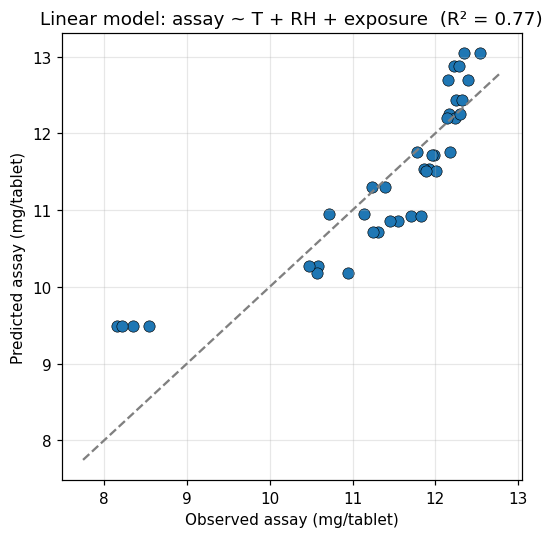

In [11]:
# Predicted vs observed for assay (best-fitting response)
from numpy.linalg import lstsq
y = stressed["assay"].values.astype(float)
beta2, *_ = lstsq(X, y, rcond=None)
yhat2 = X @ beta2
ss_res = float(((y - yhat2)**2).sum())
ss_tot = float(((y - y.mean())**2).sum())
r2_assay = 1 - ss_res / ss_tot

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y, yhat2, s=55, edgecolor="k", linewidth=0.4)
lo, hi = y.min()*0.95, y.max()*1.02
ax.plot([lo,hi],[lo,hi], "--", color="grey")
ax.set_xlabel("Observed assay (mg/tablet)")
ax.set_ylabel("Predicted assay (mg/tablet)")
ax.set_title(f"Linear model: assay ~ T + RH + exposure  (R² = {r2_assay:.2f})")
plt.tight_layout()
plt.show()

**Approach:** simple multivariate linear regression (OLS) per response using
the three predictors: temperature, humidity and exposure time.

**What it shows:**
- **Assay** is modelled reasonably well (R² ≈ 0.77). Temperature and time are
  the dominant terms — humidity's coefficient is near zero.
- **Imp 0.92** fits poorly (R² ≈ 0.42), suggesting the relationship is
  non-linear or involves an interaction not captured here.
- **Imp 1.23** gives a negative exposure coefficient — a design artefact, as
  discussed in Q3. The model should not be used to predict this response.


## Q6. Limitations and recommended next steps

**Limitations**

1. **Mass-balance gap (most critical).** ~35% potency loss at the harshest
   conditions is not explained by ~0.4% measured impurities. The fate of the
   lost active is unknown and must be resolved before any quality claim is made.
2. **Confounded design.** Temperature, humidity and exposure time are not
   independently varied — limiting causal inference and producing at least one
   spurious correlation (Imp 1.23 vs time).
3. **Single time point per condition.** Most conditions have one exposure
   duration, making kinetic modelling impossible.
4. **Duplicate ≠ independent replicate.** The two measurements capture
   analytical precision only, not batch-to-batch or tablet-to-tablet variability.

**Recommended next steps (priority order)**

1. Identify what happens to the active at 70 °C — check for volatilisation,
   run a mass-balance using a total-degradant method.
2. Run a proper factorial design (e.g. full grid of T × RH × time) with
   multiple time points per condition to enable kinetic modelling.
3. Include replicate batches per formulation to confirm the A-vs-B impurity
   difference is real and not a single-batch artefact.
4. Add multiple time-zero controls and mid-study pulls to track baseline drift.